# DATA PREPROCESSING

- Import libraries

In [2]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

- Specify folder path and the given channel names and their labels accordingly

In [3]:
base_dir = "/home/niranjanrao07/ML-project"
folders = ["ADHD_part1", "ADHD_part2", "Control_part1", "Control_part2"]

channel_map = {
    1: "Fp1",
    2: "Fp2",
    3: "F3",
    4: "F4",
    5: "C3",
    6: "C4",
    7: "P3",
    8: "P4",
    9: "O1",
    10: "O2",
    11: "F7",
    12: "F8",
    13: "T7",
    14: "T8",
    15: "P7",
    16: "P8",
    17: "Fz",
    18: "Cz",
    19: "Pz"
}

- Iterate over each folder
- Load each .mat file
- extract primary variable(not system keys)
- print out shape and basic stats
- store in a dict

In [4]:
data_dict = {}
for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    data_dict[folder] = []
    for filename in os.listdir(folder_path):
        if filename.endswith('.mat'):
            file_path = os.path.join(folder_path, filename)
            mat_data = loadmat(file_path)
            key_list = [k for k in mat_data.keys() if not k.startswith('__')]
            if key_list:
                var_key = key_list[0]
                arr = mat_data[var_key]
                print(folder, filename, arr.shape)
                print("Min:", arr.min())
                print("Max:", arr.max())
                print("Mean:", arr.mean())
                print("Std:", arr.std())
                data_dict[folder].append(arr)
                print() 


ADHD_part1 v39p.mat (18177, 19)
Min: -2155.0
Max: 4802.0
Mean: 143.01710953402653
Std: 185.34996654924797

ADHD_part1 v21p.mat (16574, 19)
Min: -3443
Max: 2776
Mean: 146.47751392479026
Std: 173.22174197119776

ADHD_part1 v19p.mat (23063, 19)
Min: -2375
Max: 2849
Mean: 146.71854668105897
Std: 221.6140830025028

ADHD_part1 v12p.mat (17604, 19)
Min: -2891
Max: 2408
Mean: 152.64647089776247
Std: 280.42539810288145

ADHD_part1 v40p.mat (20097, 19)
Min: -3663
Max: 2996
Mean: 144.86577729590434
Std: 239.3557352024789

ADHD_part1 v28p.mat (27612, 19)
Min: -3075
Max: 2444
Mean: 143.753215611824
Std: 192.56108208585482

ADHD_part1 v6p.mat (17561, 19)
Min: -13237
Max: 13813
Mean: 146.939459148412
Std: 278.1292354978769

ADHD_part1 v20p.mat (35328, 19)
Min: -3111
Max: 3843
Mean: 146.43619940646454
Std: 178.0263979208222

ADHD_part1 v29p.mat (24193, 19)
Min: -3921
Max: 3289
Mean: 143.4510939440943
Std: 297.8908190068885

ADHD_part1 v8p.mat (15776, 19)
Min: -1934
Max: 2479
Mean: 139.769990391801
Std

### FILTERING USING BUTTERWORTH-BANDPASS TECHNIQUE

- In EEG data it is known that we should remove low-frequency drift and high frequency noise
- In order to do this we generate coefficients for something called Butterworth bandpass filter and apply this filter on an input signal
- we expect that this filter should not change the number of samples or the channels since it is applied along the time dimension.

In [5]:
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    filtered_data = filtfilt(b, a, data, axis=0)
    return filtered_data

fs = 128
lowcut = 1.0
highcut = 50.0

sample_file_path = os.path.join(base_dir, "ADHD_part1", "v39p.mat")
sample_data = loadmat(sample_file_path)['v39p']
filtered_sample_data = bandpass_filter(sample_data, lowcut, highcut, fs)

print("Original shape:", sample_data.shape)
print("Filtered shape:", filtered_sample_data.shape)


Original shape: (18177, 19)
Filtered shape: (18177, 19)


- So we can see the from the output, the filtering processing was a success. But I am a bit skeptical if its actually working, so I will plot a graph agaist the raw data and the filtered data and check the mean and see if it has smoothed out some of the noise while preserving the overall waveform shape.

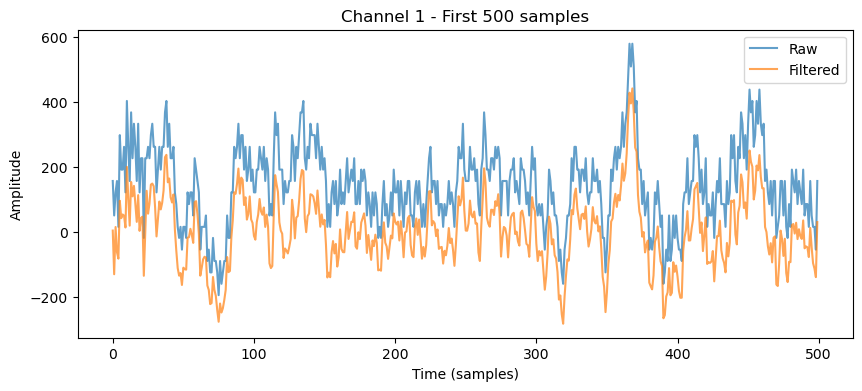

Raw data stats (channel 1):
Mean: 143.472 Std: 121.29107640712898
Filtered data stats (channel 1):
Mean: 1.1253322745491714 Std: 108.0135333341197


In [6]:
import matplotlib.pyplot as plt

# Let's pick the first 500 samples of one channel for demonstration
channel_index = 0
num_samples = 500

raw_segment = sample_data[:num_samples, channel_index]
filtered_segment = filtered_sample_data[:num_samples, channel_index]

# Plotting the raw vs. filtered segment
plt.figure(figsize=(10, 4))
plt.plot(raw_segment, label='Raw', alpha=0.7)
plt.plot(filtered_segment, label='Filtered', alpha=0.7)
plt.title(f"Channel {channel_index + 1} - First {num_samples} samples")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# Print basic stats
print("Raw data stats (channel 1):")
print("Mean:", raw_segment.mean(), "Std:", raw_segment.std())

print("Filtered data stats (channel 1):")
print("Mean:", filtered_segment.mean(), "Std:", filtered_segment.std())


- Yes it seems to be working fine, I shall go ahead and apply this on the entire dataset.
- I do not want to modify the original dataset and want to keep things clean, so what I am going to do is apply the filtering first, create an output folder with filtered data and place the fitered dataset in this new folder for further preprocessing techiniques like normalization...

In [7]:
import os
import numpy as np
from scipy.io import loadmat, savemat
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    filtered_data = filtfilt(b, a, data, axis=0)
    return filtered_data

base_dir = "/home/niranjanrao07/ML-project"
folders = ["ADHD_part1", "ADHD_part2", "Control_part1", "Control_part2"]

fs = 128
lowcut = 1.0
highcut = 50.0

output_folder = os.path.join(base_dir, "FilteredData")
os.makedirs(output_folder, exist_ok=True)

for folder in folders:
    folder_path = os.path.join(base_dir, folder)
    filtered_folder_path = os.path.join(output_folder, folder)
    os.makedirs(filtered_folder_path, exist_ok=True)
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.mat'):
            file_path = os.path.join(folder_path, filename)
            mat_data = loadmat(file_path)
            
            # Identify the main variable key
            keys = [k for k in mat_data.keys() if not k.startswith('__')]
            if not keys:
                continue
            
            var_key = keys[0]
            arr = mat_data[var_key]
            
            filtered_arr = bandpass_filter(arr, lowcut, highcut, fs)
            
            # Save the filtered data as a new MAT file
            save_path = os.path.join(filtered_folder_path, filename)
            savemat(save_path, {var_key: filtered_arr})
            
            print(f"Filtered {filename} -> {save_path} (shape: {filtered_arr.shape})")


Filtered v39p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v39p.mat (shape: (18177, 19))
Filtered v21p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v21p.mat (shape: (16574, 19))
Filtered v19p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v19p.mat (shape: (23063, 19))
Filtered v12p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v12p.mat (shape: (17604, 19))
Filtered v40p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v40p.mat (shape: (20097, 19))
Filtered v28p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v28p.mat (shape: (27612, 19))
Filtered v6p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v6p.mat (shape: (17561, 19))
Filtered v20p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v20p.mat (shape: (35328, 19))
Filtered v29p.mat -> /home/niranjanrao07/ML-project/FilteredData/ADHD_part1/v29p.mat (shape: (24193, 19))
Filtered v8p.mat -> /home/niranjanrao07/ML-proje

### Normalization Step

- In this step I want to perform z-score normalization on the filtered dataset I got from the last output. 
- For each channel, I will subtract the mean and divide by the standard deviation, to make sure that all channels have zero mean and unit variance. 
- This process helps standardize the amplitude range across different subjects and sessions, reducing variability that can arise from differences in electrode placement, individual physiology, or other recording conditions. 
- The resulting normalized data is saved in a separate folder called NormalizedData so that we have a clean pipeline of RawData, Filtered Data and Normalized Data.


In [ ]:
import os
import numpy as np
from scipy.io import loadmat, savemat

def zscore_normalize(data):
    means = np.mean(data, axis=0)
    stds = np.std(data, axis=0)
    stds[stds == 0] = 1e-7
    return (data - means) / stds

filtered_dir = os.path.join(base_dir, "FilteredData")
normalized_dir = os.path.join(base_dir, "NormalizedData")
os.makedirs(normalized_dir, exist_ok=True)

for folder in folders:
    filtered_folder_path = os.path.join(filtered_dir, folder)
    normalized_folder_path = os.path.join(normalized_dir, folder)
    os.makedirs(normalized_folder_path, exist_ok=True)
    
    for filename in os.listdir(filtered_folder_path):
        if filename.endswith('.mat'):
            file_path = os.path.join(filtered_folder_path, filename)
            mat_data = loadmat(file_path)
            keys = [k for k in mat_data.keys() if not k.startswith('__')]
            if not keys:
                continue
            var_key = keys[0]
            arr = mat_data[var_key]
            
            normalized_arr = zscore_normalize(arr)
            
            save_path = os.path.join(normalized_folder_path, filename)
            savemat(save_path, {var_key: normalized_arr})
            print(f"Normalized {filename} -> {save_path} (shape: {normalized_arr.shape})")


Normalized v39p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v39p.mat (shape: (18177, 19))
Normalized v21p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v21p.mat (shape: (16574, 19))
Normalized v19p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v19p.mat (shape: (23063, 19))
Normalized v12p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v12p.mat (shape: (17604, 19))
Normalized v40p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v40p.mat (shape: (20097, 19))
Normalized v28p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v28p.mat (shape: (27612, 19))
Normalized v6p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v6p.mat (shape: (17561, 19))
Normalized v20p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v20p.mat (shape: (35328, 19))
Normalized v29p.mat -> /home/niranjanrao07/ML-project/NormalizedData/ADHD_part1/v29p.mat (shape: (24193, 19))
Normalized v

### Artifact Removal

- In this step I want to perform a simple amplitude-based artifact removal. 
- I want to replace any data point in the normalized dataset that exceeds a specified threshold with `NaN`. 
- The cleaned data is saved in a new directory.


In [ ]:
import os
import numpy as np
from scipy.io import loadmat, savemat

def remove_normalized_outliers(data, threshold=3):
    data_out = data.copy()
    mask = np.abs(data_out) > threshold
    data_out[mask] = np.nan
    return data_out

artifact_threshold = 3

normalized_dir = os.path.join(base_dir, "NormalizedData")
artifact_free_dir = os.path.join(base_dir, "ArtifactFreeData")
os.makedirs(artifact_free_dir, exist_ok=True)

for folder in folders:
    normalized_folder_path = os.path.join(normalized_dir, folder)
    artifact_folder_path = os.path.join(artifact_free_dir, folder)
    os.makedirs(artifact_folder_path, exist_ok=True)

    for filename in os.listdir(normalized_folder_path):
        if filename.endswith('.mat'):
            file_path = os.path.join(normalized_folder_path, filename)
            mat_data = loadmat(file_path)
            keys = [k for k in mat_data.keys() if not k.startswith('__')]
            if not keys:
                continue

            var_key = keys[0]
            arr = mat_data[var_key]

            cleaned_arr = remove_normalized_outliers(arr, threshold=artifact_threshold)

            save_path = os.path.join(artifact_folder_path, filename)
            savemat(save_path, {var_key: cleaned_arr})
            print(f"Cleaned {filename} -> {save_path} (shape: {cleaned_arr.shape})")


Cleaned v39p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v39p.mat (shape: (18177, 19))
Cleaned v21p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v21p.mat (shape: (16574, 19))
Cleaned v19p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v19p.mat (shape: (23063, 19))
Cleaned v12p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v12p.mat (shape: (17604, 19))
Cleaned v40p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v40p.mat (shape: (20097, 19))
Cleaned v28p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v28p.mat (shape: (27612, 19))
Cleaned v6p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v6p.mat (shape: (17561, 19))
Cleaned v20p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v20p.mat (shape: (35328, 19))
Cleaned v29p.mat -> /home/niranjanrao07/ML-project/ArtifactFreeData/ADHD_part1/v29p.mat (shape: (24193, 19))
Cleaned v8p.mat -> /h

In [16]:
artifact_dir = os.path.join(base_dir, "ArtifactFreeData")

for folder in folders:
    folder_path = os.path.join(artifact_dir, folder)
    print(f"--- Folder: {folder} ---")
    for filename in os.listdir(folder_path):
        if filename.endswith('.mat'):
            file_path = os.path.join(folder_path, filename)
            data = loadmat(file_path)
            keys = [k for k in data.keys() if not k.startswith('__')]
            if not keys:
                continue
            var_key = keys[0]
            arr = data[var_key]
            print(f"{folder} {filename} {arr.shape}")
            print("Min:", np.nanmin(arr))
            print("Max:", np.nanmax(arr))
            print("Mean:", np.nanmean(arr))
            print("Std:", np.nanstd(arr))
            print()


--- Folder: ADHD_part1 ---
ADHD_part1 v39p.mat (18177, 19)
Min: -2.999690332792243
Max: 2.998984098017921
Mean: 0.0019466612148038025
Std: 0.9302706940086254

ADHD_part1 v21p.mat (16574, 19)
Min: -2.9987471950159734
Max: 2.999588155264899
Mean: -0.0013348363753932588
Std: 0.9025888064627289

ADHD_part1 v19p.mat (23063, 19)
Min: -2.9987268753994534
Max: 2.9996016207155654
Mean: -0.0007901616324581664
Std: 0.9179840340246347

ADHD_part1 v12p.mat (17604, 19)
Min: -2.9995632958928953
Max: 2.999803905415824
Mean: -0.007133316625660176
Std: 0.9092798427994038

ADHD_part1 v40p.mat (20097, 19)
Min: -2.9997248735921134
Max: 2.9999502197186345
Mean: -0.0026861777827962945
Std: 0.8427592710724054

ADHD_part1 v28p.mat (27612, 19)
Min: -2.9999732408678197
Max: 2.999774766748696
Mean: -0.0032083132270985513
Std: 0.8935879175870503

ADHD_part1 v6p.mat (17561, 19)
Min: -2.9994221836518418
Max: 2.999868191410589
Mean: -0.0004505558780663419
Std: 0.8855795052081488

ADHD_part1 v20p.mat (35328, 19)
Min: 

- After playing around with the threshold values - I landed on threshold = 3
- NaN values in the entire dataset is less than 3% is some channels and less than 1% is most channels which is acceptable
- This gave me the best results with datapoints falling between +/- 3 and Standard deviations around 0.8-1.0.
- Outlier removal was a success